<a href="https://colab.research.google.com/github/anjipandey16/IITD/blob/main/Fraud%20Detection%20for%20Digital%20Payment%20Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import numpy as np # library for numerical operations
import pandas as pd # library for data manipulation and analysis
import pydotplus # library for creating and displaying graphs from dot files

from sklearn import tree # module for decision tree algorithms
from sklearn.model_selection import train_test_split # module for splitting data into training and testing sets
from sklearn.tree import DecisionTreeClassifier # class for creating a decision tree classifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import export_graphviz # function for exporting decision tree in DOT format
from sklearn.metrics import accuracy_score # function for calculating accuracy score
from sklearn.metrics import confusion_matrix # function for calculating confusion matrix
from six import StringIO # class for working with strings as file-like objects
from IPython.display import Image # class for displaying images in IPython environment



In [42]:
input_file = pd.read_csv("/content/sample_data/SynthBank-Fraud v1.0.csv")
input_file.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   txn_id             10000 non-null  int64  
 1   timestamp          10000 non-null  object 
 2   user_id            10000 non-null  int64  
 3   amount             10000 non-null  float64
 4   merchant_category  10000 non-null  object 
 5   channel            10000 non-null  object 
 6   is_fraud           10000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 547.0+ KB


In [43]:
input_file.isna().sum()

,0
txn_id,0
timestamp,0
user_id,0
amount,0
merchant_category,0
channel,0
is_fraud,0


In [45]:
input_file['timestamp']=pd.to_datetime(input_file['timestamp'])
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
input_file['merchant_category'] = le.fit_transform(input_file['merchant_category'])
input_file['channel'] = le.fit_transform(input_file['channel'])
transaction_date = input_file['timestamp'].dt.month
input_file['t_day'] = input_file['timestamp'].dt.day
input_file['t_month'] = input_file['timestamp'].dt.month
input_file['t_year'] = input_file['timestamp'].dt.year
input_file['t_time'] = input_file['timestamp'].dt.time
input_file.head()


,txn_id,timestamp,user_id,amount,merchant_category,channel,is_fraud,t_day,t_month,t_year,t_time
0,1,2023-01-01 09:05:00,183,18.91,5,3,0,1,1,2023,09:05:00
1,2,2023-01-01 09:15:00,220,33.49,7,0,0,1,1,2023,09:15:00
2,3,2023-01-01 09:15:00,460,18.82,4,3,0,1,1,2023,09:15:00
3,4,2023-01-01 09:27:00,256,38.09,0,3,0,1,1,2023,09:27:00
4,5,2023-01-01 09:28:00,102,45.11,1,2,0,1,1,2023,09:28:00


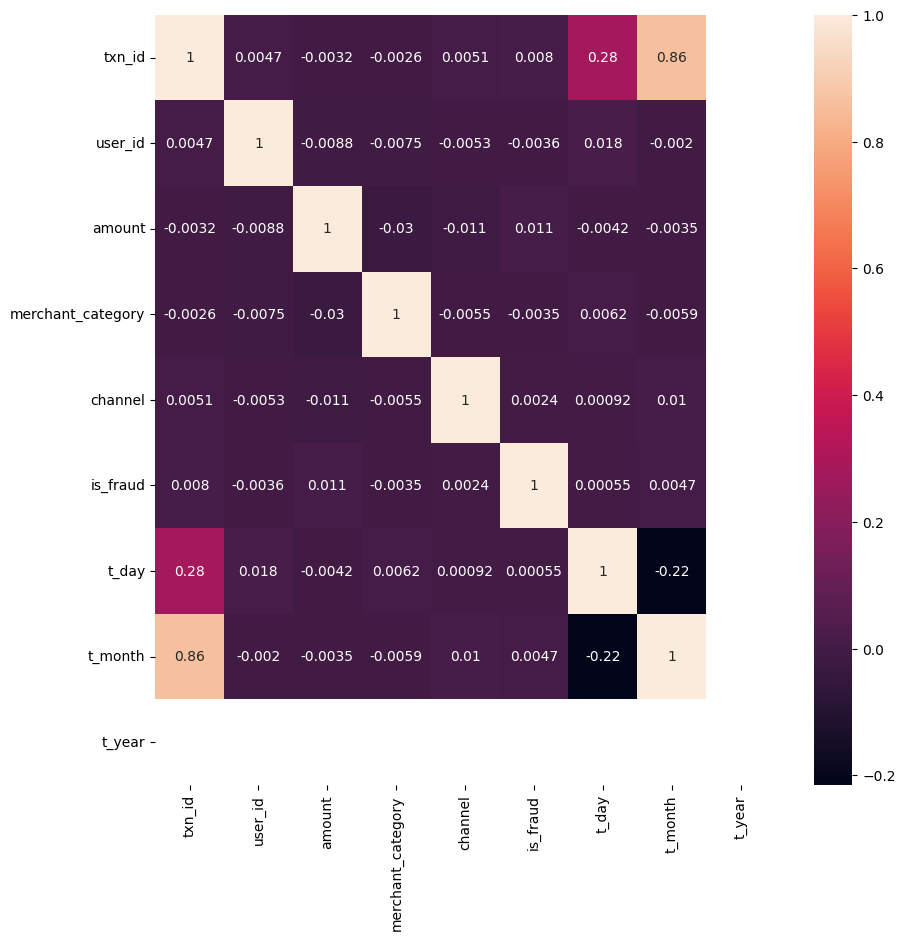

In [46]:
corr_matrix = input_file.select_dtypes('number').corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True)
plt.show()

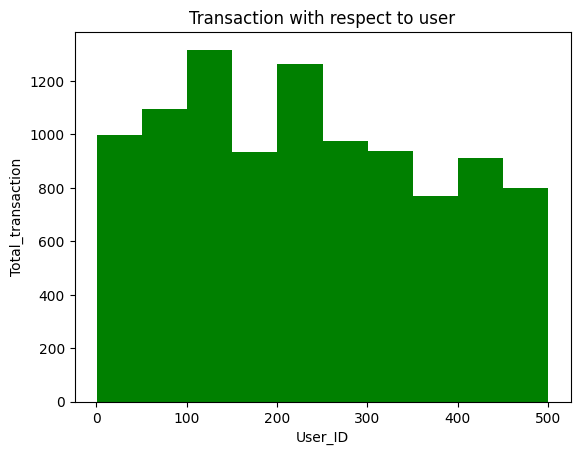

In [48]:

input_file.groupby("txn_id")['user_id'].sum().plot(kind='hist',color='green')
plt.title("Transaction with respect to user")
plt.xlabel("User_ID")
plt.ylabel("Total_transaction")
plt.show()

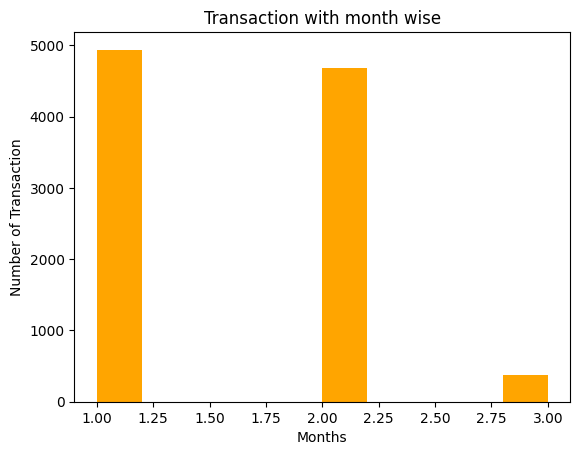

In [49]:

input_file.groupby("txn_id")['t_month'].sum().plot(kind='hist',color='orange')
plt.title("Transaction with month wise")
plt.xlabel("Months")
plt.ylabel("Number of Transaction")
plt.show()

In [54]:
#split dataset in features and target variable

feature_cols = ['txn_id','user_id','amount','merchant_category','channel','t_day','t_month','t_year']
label =  ['is_fraud']   #Features used for the example
X = input_file[feature_cols]                                # Features
y = input_file[label]                                        # Target variable

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [58]:
model = LogisticRegression()
model.fit(X_train, y_train)
#Predict the response for test dataset
y_pred = model.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy: {:.2f}".format(accuracy_score(y_test, y_pred)*100))
cm=confusion_matrix(y_test, y_pred)
print("Confusion matrix \n", cm)

Accuracy: 99.10
Confusion matrix 
 [[2973    0]
 [  27    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy: {:.2f}".format(accuracy_score(y_test, y_pred)*100))
cm=confusion_matrix(y_test, y_pred)
print("Confusion matrix \n", cm)

Accuracy: 99.03
Confusion matrix 
 [[2971    2]
 [  27    0]]


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (10000,) and arg 1 with shape (8, 6).

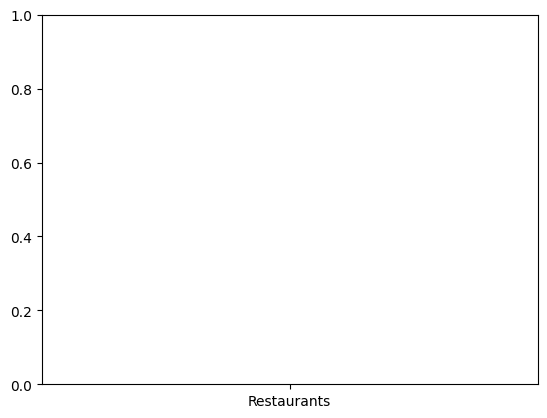

In [ ]:
values = input_file.groupby('merchant_category').count()
plt.bar(input_file['merchant_category'], values, color='skyblue')
plt.title('Basic Bar Chart (Matplotlib)')
plt.xlabel('Categories')
plt.ylabel('Values')
plt.show()

